# 서울 자치구 군집 분석 (2020~2024)

**분석 목적**: 서울 25개 자치구 × 5개 연도(2020~2024) 패널 데이터를 활용하여  
자치구별 사회·경제·주거 특성을 기반으로 지역 유형을 도출한다.

| 항목 | 내용 |
|------|------|
| 데이터 | `final_dataset.csv` — 서울 자치구 × 연도 패널 (25개 자치구 × 5개 연도 = 125행) |
| 목적 | K-means 클러스터링을 통한 지역 유형화 |
| 최종 군집 수 | **k = 4** |
| 재현 조건 | `random_state=42` 고정, 결과 100% 재현 가능 |


In [1]:
# ── 라이브러리 임포트 ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# 한글 지원 폰트 자동 탐지
KOREAN_FONT_CANDIDATES = [
    'Noto Sans CJK KR', 'Noto Sans CJK JP',  # Linux 서버
    'AppleGothic', 'Apple SD Gothic Neo',      # macOS
    'Malgun Gothic', 'NanumGothic',            # Windows / 설치 폰트
]

available = {f.name for f in fm.fontManager.ttflist}
korean_font = next((f for f in KOREAN_FONT_CANDIDATES if f in available), None)

if korean_font:
    plt.rcParams['font.family'] = korean_font
    print(f'✅ 한글 폰트 설정: {korean_font}')
else:
    print('⚠️ 한글 폰트를 찾을 수 없습니다. 그래프 레이블이 영문으로 표시됩니다.')

plt.rcParams['axes.unicode_minus'] = False

# ── 재현성 고정 ────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ 라이브러리 로드 및 환경 설정 완료')
print(f'   pandas {pd.__version__} / numpy {np.__version__}')

✅ 한글 폰트 설정: Malgun Gothic
✅ 라이브러리 로드 및 환경 설정 완료
   pandas 2.1.4 / numpy 1.26.4


---
## Step 1. 데이터 검증 (EDA)

**한 줄 요약**: 원본 데이터를 로드하고 분포·이상치·결측치·상관관계를 확인한다.

**수행 목적**: 클러스터링 전 데이터 품질과 변수 특성을 파악하여 전처리 방향을 결정한다.

> **데이터 딕셔너리 요약**  
> - 식별자: `district`(자치구), `year`(연도)  
> - 인구: `total_population`, `pop_0_14`, `pop_15_64`, `pop_65p`, `population_density`, 연령대 비율 3종  
> - 가구: `total_households`, `single_households`, `avg_household_size`, `single_household_ratio`  
> - 사업체: `num_businesses`, `num_workers`, `worker_density`  
> - 소비/직장/생활인구: `consumption_total`, `working_population`, `working_pop_ratio`, `living_population`, `living_pop_ratio`  
> - 토지: `residential_area`, `commercial_area`, `residential_ratio`, `commercial_ratio`  
> - 주택: `total_housing`, `apartment_count`, `non_apartment_count`, `apartment_ratio`, `non_apartment_ratio`, `housing_density`


In [2]:
# ── 1-1. 데이터 로드 ──────────────────────────────────────────────────────────
df = pd.read_csv('final_dataset.csv')

print(f'Shape: {df.shape}')
print(f'자치구 ({df["district"].nunique()}개): {sorted(df["district"].unique().tolist())}')
print(f'연도: {sorted(df["year"].unique().tolist())}')
df.head()

Shape: (125, 33)
자치구 (25개): ['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구', '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구', '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구']
연도: [2020, 2021, 2022, 2023, 2024]


,district,year,total_population,pop_0_14,pop_15_64,pop_65p,population_density,age_0_14_ratio,age_15_64_ratio,age_65_plus_ratio,...,residential_area,commercial_area,residential_ratio,commercial_ratio,total_housing,apartment_count,non_apartment_count,apartment_ratio,non_apartment_ratio,housing_density
0,강남구,2020,539231,65904,398368,74959,13651.417722,0.122218,0.738771,0.139011,...,24.228249,1.946139,0.613373,0.049269,173745,126023,45985,0.725333,0.264669,4398.607595
1,강남구,2021,533042,64520,390444,78078,13494.734177,0.121041,0.732483,0.146476,...,24.227238,1.947150,0.613348,0.049295,175536,128437,45467,0.731685,0.259018,4443.949367
2,강남구,2022,529102,62278,385260,81564,13394.987342,0.117705,0.728139,0.154156,...,24.224319,1.950069,0.613274,0.049369,178493,131599,45341,0.737278,0.254021,4518.810127
3,강남구,2023,544873,63911,394528,86434,13794.253165,0.117295,0.724073,0.158631,...,24.229460,1.950392,0.613404,0.049377,184608,138025,45035,0.747665,0.243949,4673.620253
4,강남구,2024,557345,65556,400498,91291,14106.428752,0.117622,0.718582,0.163796,...,24.189066,1.677377,0.612226,0.042454,192220,145996,44695,0.759526,0.232520,4865.097444


In [3]:
# ── 1-2. 기초 통계량 (변동계수 포함) ────────────────────────────────────────
desc = df.describe().T
desc['cv'] = (desc['std'] / desc['mean']).abs().round(3)  # 변동계수(Coefficient of Variation)
print('기초 통계량')
desc[['mean', 'std', 'cv', 'min', '25%', '50%', '75%', 'max']].round(3)

기초 통계량


,mean,std,cv,min,25%,50%,75%,max
year,2.022000e+03,1.420000e+00,0.001,2.020000e+03,2.021000e+03,2.022000e+03,2.023000e+03,2.024000e+03
total_population,3.785933e+05,1.256220e+05,0.332,1.204370e+05,3.048190e+05,3.794800e+05,4.609190e+05,6.679600e+05
pop_0_14,3.647336e+04,1.624006e+04,0.445,8.119000e+03,2.646100e+04,3.332500e+04,4.879300e+04,7.980500e+04
pop_15_64,2.752077e+05,9.206366e+04,0.335,8.601700e+04,2.181360e+05,2.776000e+05,3.323430e+05,4.948460e+05
pop_65p,6.691217e+04,2.029506e+04,0.303,2.403700e+04,5.423100e+04,6.847300e+04,8.023200e+04,1.139570e+05
population_density,1.638196e+04,4.545841e+03,0.277,5.785696e+03,1.379425e+04,1.629882e+04,1.943146e+04,2.609138e+04
age_0_14_ratio,9.300000e-02,1.600000e-02,0.176,5.400000e-02,8.200000e-02,9.200000e-02,1.040000e-01,1.340000e-01
age_15_64_ratio,7.270000e-01,1.700000e-02,0.024,6.790000e-01,7.160000e-01,7.250000e-01,7.350000e-01,7.710000e-01
age_65_plus_ratio,1.800000e-01,2.300000e-02,0.125,1.390000e-01,1.640000e-01,1.780000e-01,1.930000e-01,2.510000e-01
area,2.421000e+01,9.160000e+00,0.378,9.960000e+00,1.741000e+01,2.360000e+01,2.957000e+01,4.698000e+01


In [4]:
# ── 1-3. 결측치 확인 ──────────────────────────────────────────────────────────
missing = df.isnull().sum()
print('결측치 합계:')
print(missing[missing > 0] if missing.any() else '결측치 없음 ✔')

결측치 합계:
결측치 없음 ✔


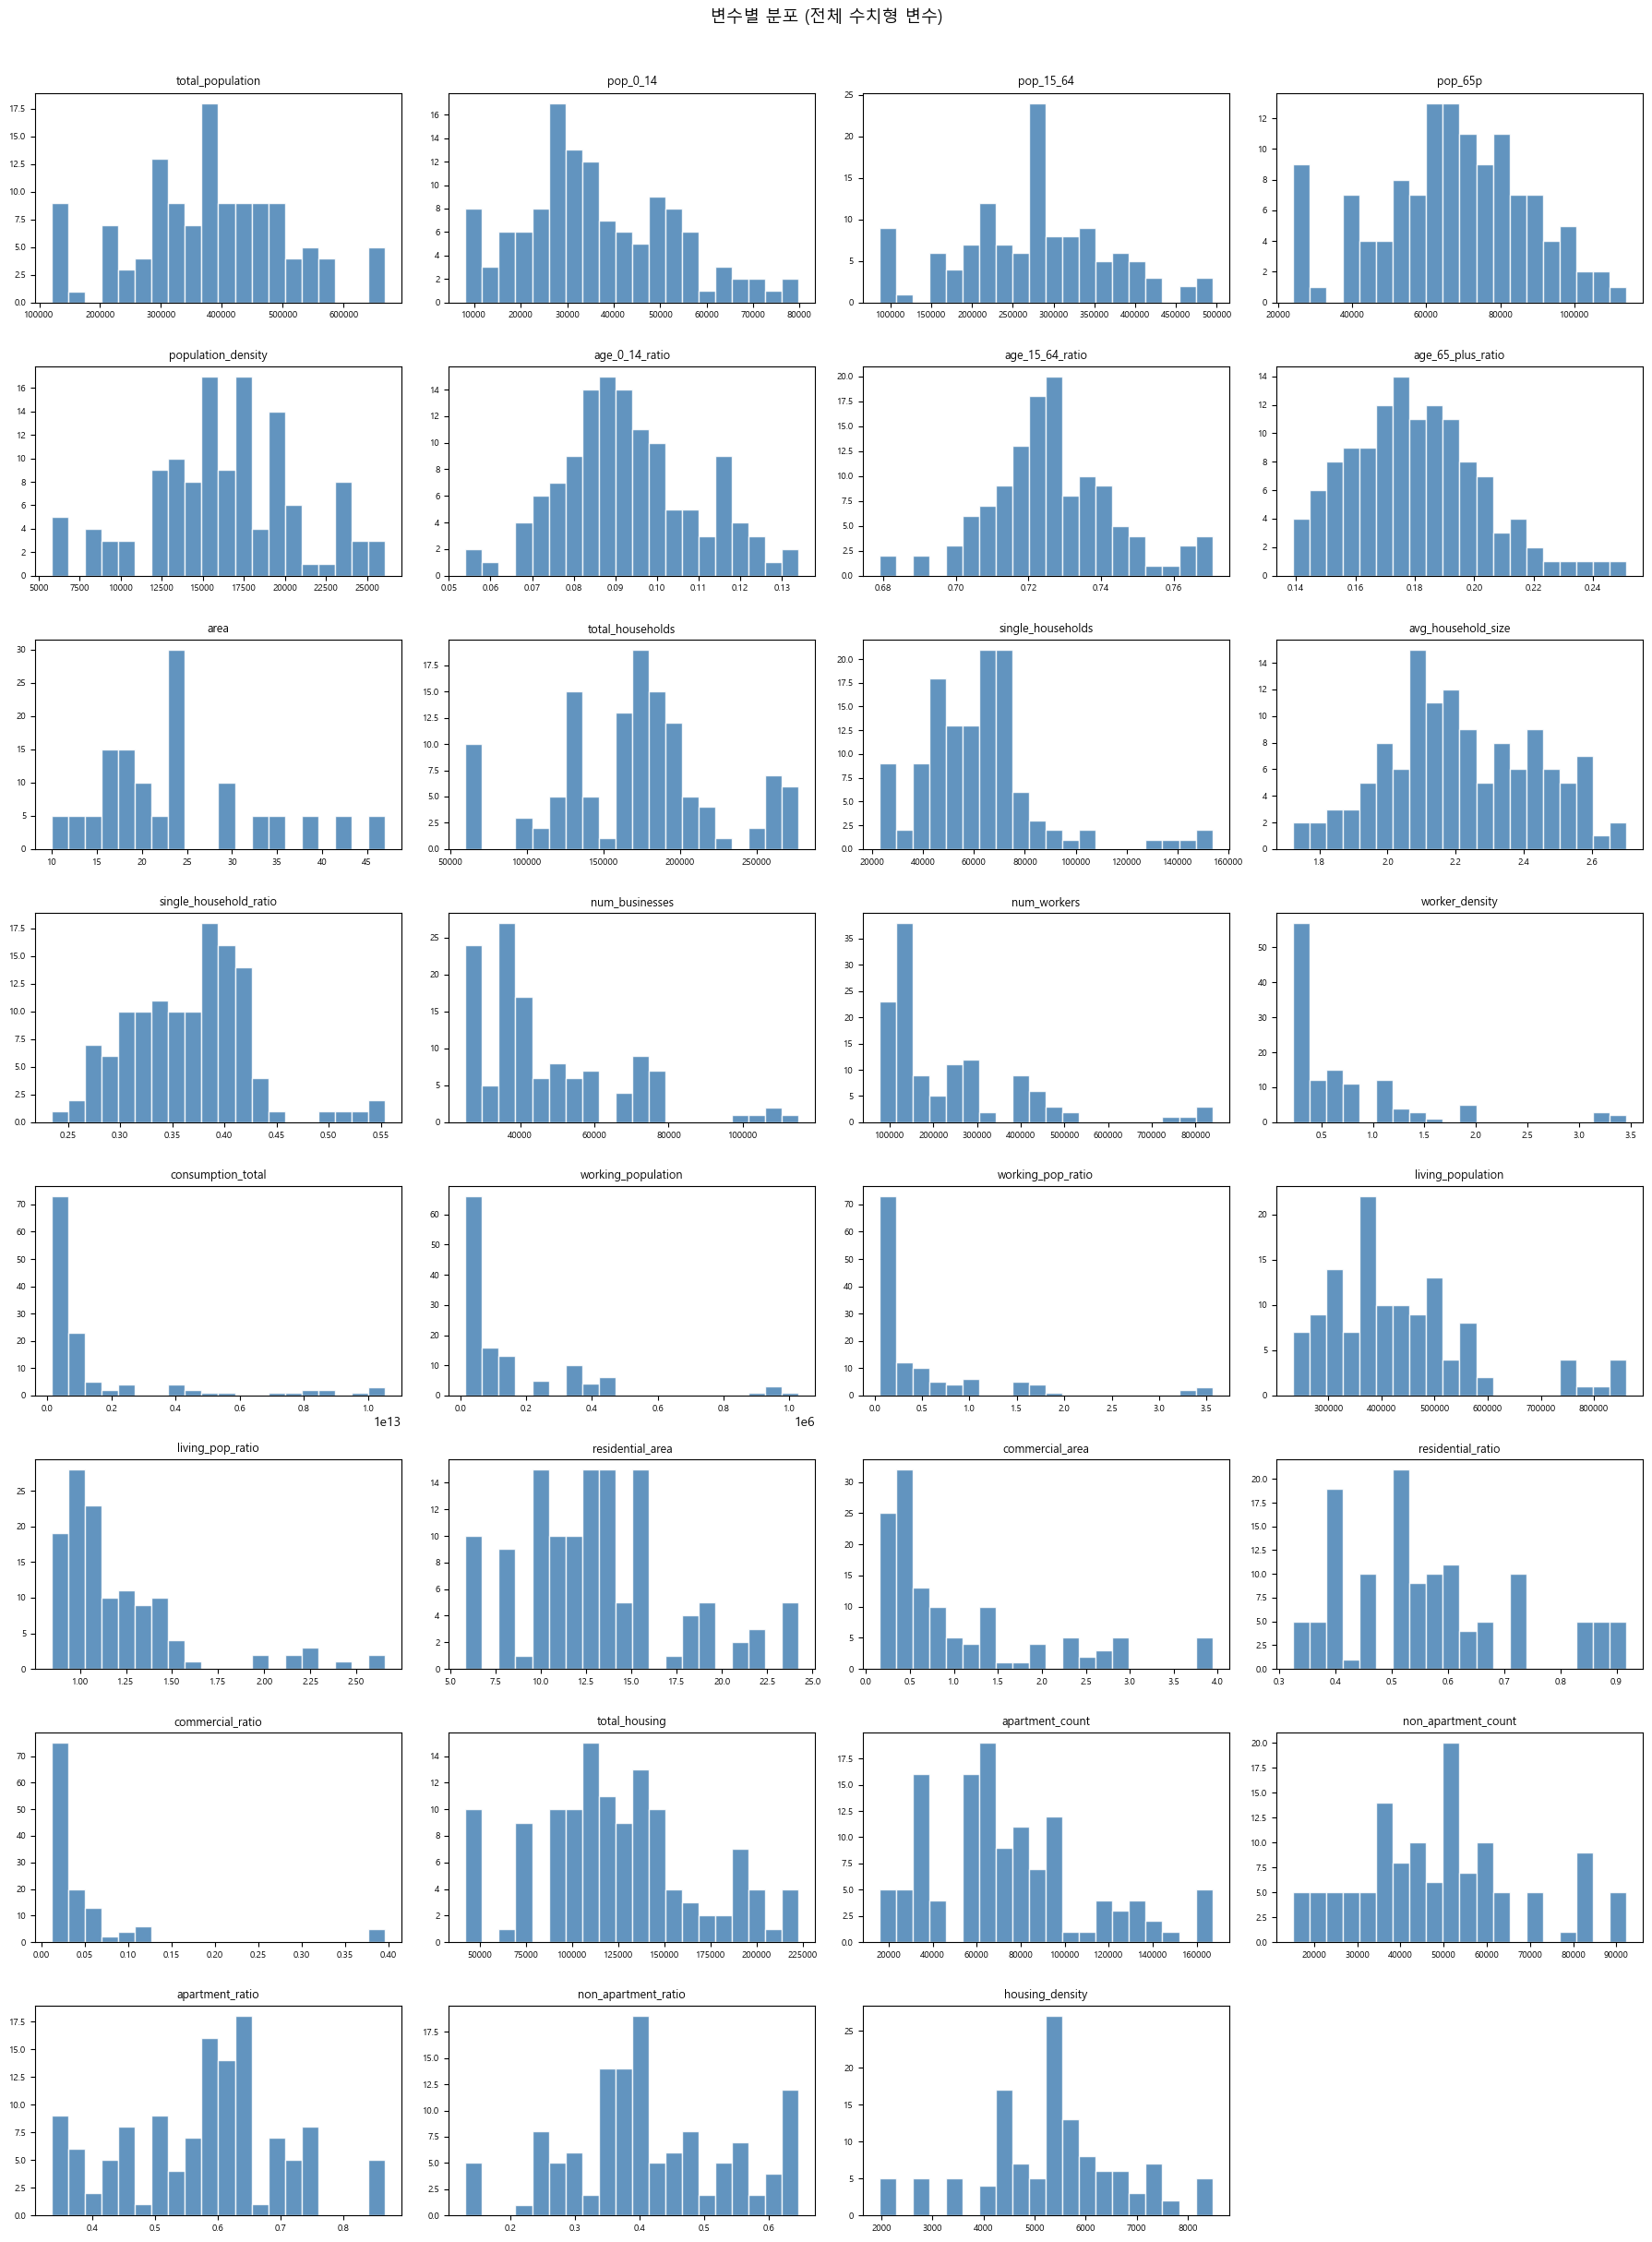

In [5]:
# ── 1-4. 수치형 변수 분포 시각화 ─────────────────────────────────────────────
num_cols = df.select_dtypes(include='number').columns.drop('year')

n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('변수별 분포 (전체 수치형 변수)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_01_distributions.png', bbox_inches='tight')
plt.show()

In [6]:
# ── 1-5. 이상치 확인 (IQR 기준) ──────────────────────────────────────────────
outlier_summary = []
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    outlier_summary.append({'변수명': col, '이상치 수': n_out, '비율(%)': round(n_out / len(df) * 100, 1)})

out_df = pd.DataFrame(outlier_summary).sort_values('이상치 수', ascending=False)
print('IQR 기준 이상치 상위 10개 변수')
out_df[out_df['이상치 수'] > 0].head(10)

IQR 기준 이상치 상위 10개 변수


,변수명,이상치 수,비율(%)
17,working_population,25,20.0
16,consumption_total,19,15.2
24,commercial_ratio,15,12.0
18,working_pop_ratio,15,12.0
15,worker_density,13,10.4
22,commercial_area,10,8.0
20,living_pop_ratio,10,8.0
19,living_population,10,8.0
6,age_15_64_ratio,6,4.8
10,single_households,6,4.8


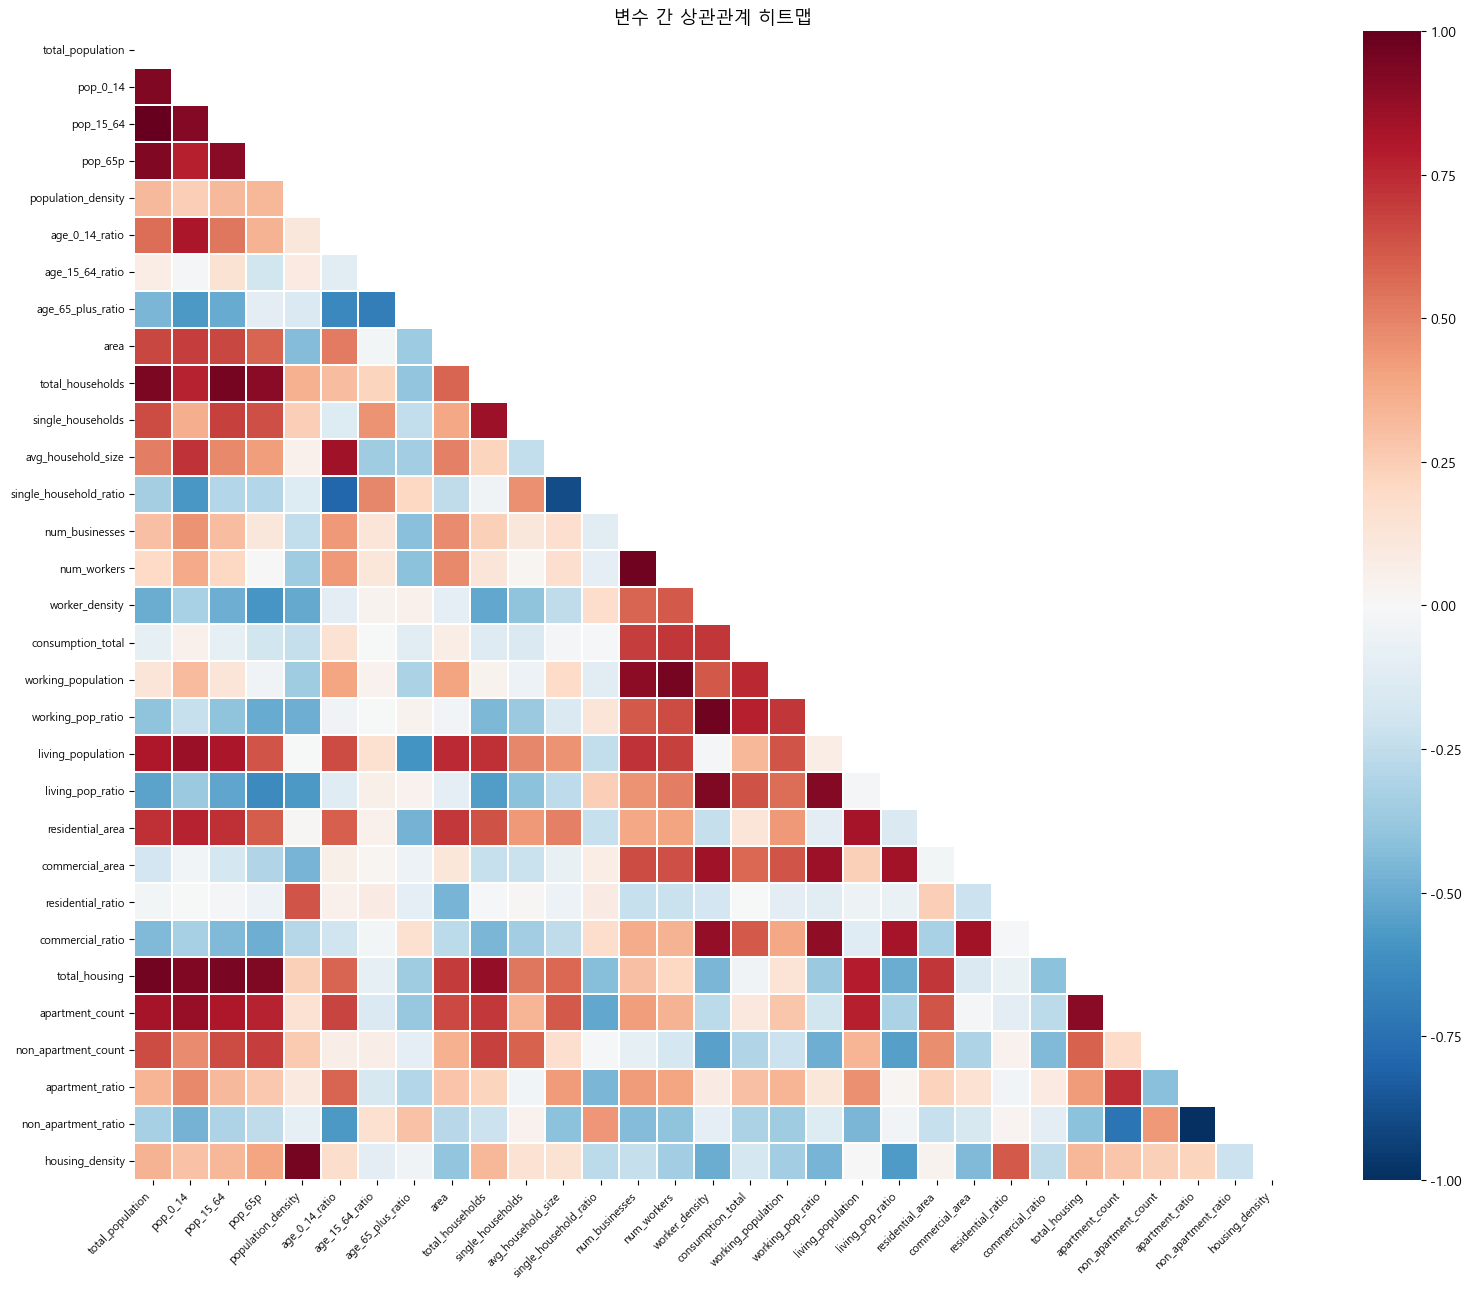

In [7]:
# ── 1-6. 상관관계 히트맵 ─────────────────────────────────────────────────────
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.3, annot_kws={'size': 6}, ax=ax
)
ax.set_title('변수 간 상관관계 히트맵', fontsize=13)
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.savefig('fig_02_correlation.png', bbox_inches='tight')
plt.show()

In [8]:
# ── 1-7. 고상관 변수 쌍 추출 (|r| >= 0.90) ────────────────────────────────────
high_corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
high_corr_pairs.columns = ['변수1', '변수2', '상관계수(r)']
high_corr_pairs = high_corr_pairs[high_corr_pairs['상관계수(r)'].abs() >= 0.90].sort_values('상관계수(r)', ascending=False)
print(f'|r| >= 0.90인 변수 쌍: {len(high_corr_pairs)}개')
high_corr_pairs.round(3)

|r| >= 0.90인 변수 쌍: 19개


,변수1,변수2,상관계수(r)
1,pop_15_64,total_population,0.997
168,working_pop_ratio,worker_density,0.972
104,num_workers,num_businesses,0.971
300,total_housing,total_population,0.967
439,housing_density,population_density,0.955
38,total_households,pop_15_64,0.955
150,working_population,num_workers,0.953
302,total_housing,pop_15_64,0.952
36,total_households,total_population,0.944
205,living_pop_ratio,worker_density,0.932


### Step 1 결과 해석

**핵심 발견사항**

1. **결측치 없음**: 125행 × 33열 전체에 결측치가 존재하지 않아 별도 대치 불필요.
2. **극단적 우편포 변수**: `num_workers`(종사자 수), `consumption_total`(연간 소비 지출), `working_population`(직장인구) 등 규모 변수는 중구·강남구 등 업무 중심지에 의해 강한 우편포를 보임 (이상치 비율 10%+).
3. **다중공선성 다수 존재**: `total_population`과 `total_households`, `pop_15_64`와 `working_population` 등 인구·가구 관련 변수 간 |r| > 0.95 이상인 쌍이 다수 → 중복 변수 제거 필요.
4. **비율 변수의 안정성**: `age_65_plus_ratio`(고령 인구 비율), `single_household_ratio`(1인 가구 비율), `apartment_ratio`(아파트 비율) 등 비율 변수는 상대적으로 분산이 안정적.
5. **경제 활동 변수**: `worker_density`(취업자 밀도), `commercial_ratio`(상업지 비율), `working_pop_ratio`(직장인구 비율)는 자치구 간 변동계수(CV)가 크며 지역 특성을 잘 반영.

---
## Step 2. 변수 선택 (Feature Selection)

**한 줄 요약**: 고상관 중복 변수를 제거하고 클러스터링에 의미 있는 핵심 변수 12개를 선별한다.

**수행 목적**: 중복 정보 제거로 군집 왜곡을 방지하고, 지역 특성을 다각도로 포괄하는 변수 세트를 구성한다.

| 제거 원칙 | 내용 |
|-----------|------|
| ① 절대 규모 변수 | `total_population`, `total_households`, `num_businesses`, `num_workers` 등 → 비율·밀도 변수로 대체 (면적·인구 규모 차이가 군집을 왜곡) |
| ② 성분 변수 | `pop_0_14`, `pop_15_64`, `pop_65p`, `apartment_count`, `non_apartment_count` → 이미 비율 변수로 포함 |
| ③ 역수 관계 변수 | `non_apartment_ratio` = 1 − `apartment_ratio` → 하나만 유지 |
| ④ 고상관 중복 변수 | `consumption_total` ↔ `working_population` (|r| > 0.95), `living_population` ↔ `working_population` 등 |


In [9]:
# ── 2-1. 변수 선택 정의 ──────────────────────────────────────────────────────
# 6개 분석 축: 인구구조 / 인구·주거 밀도 / 가구 구조 / 경제·업무 활동 / 토지 이용 / 주택 유형
selected_features = {
    # 인구 구조
    'age_0_14_ratio'        : '0~14세 비율 (유소년 인구 비율)',
    'age_65_plus_ratio'     : '65세 이상 비율 (고령 인구 비율)',
    # 인구·주거 밀도
    'population_density'    : '인구 밀도 (명/km²)',
    'housing_density'       : '주택 밀도 (호/km²)',
    # 가구 구조
    'single_household_ratio': '1인 가구 비율',
    'avg_household_size'    : '평균 가구원 수 (명/가구)',
    # 경제·업무 활동
    'worker_density'        : '취업자 밀도 (종사자 수/등록인구)',
    'working_pop_ratio'     : '직장인구 비율 (직장인구/등록인구, 1 초과 가능)',
    # 토지 이용
    'residential_ratio'     : '주거지역 비율',
    'commercial_ratio'      : '상업지역 비율',
    # 주택 유형
    'apartment_ratio'       : '아파트 비율',
    # 생활 활력
    'living_pop_ratio'      : '생활인구 비율 (통신 기반 유동인구/등록인구, 1 초과 가능)',
}

feature_cols = list(selected_features.keys())

print(f'선택된 변수 ({len(feature_cols)}개):')
for k, v in selected_features.items():
    print(f'  {k:30s}  {v}')

선택된 변수 (12개):
  age_0_14_ratio                  0~14세 비율 (유소년 인구 비율)
  age_65_plus_ratio               65세 이상 비율 (고령 인구 비율)
  population_density              인구 밀도 (명/km²)
  housing_density                 주택 밀도 (호/km²)
  single_household_ratio          1인 가구 비율
  avg_household_size              평균 가구원 수 (명/가구)
  worker_density                  취업자 밀도 (종사자 수/등록인구)
  working_pop_ratio               직장인구 비율 (직장인구/등록인구, 1 초과 가능)
  residential_ratio               주거지역 비율
  commercial_ratio                상업지역 비율
  apartment_ratio                 아파트 비율
  living_pop_ratio                생활인구 비율 (통신 기반 유동인구/등록인구, 1 초과 가능)


In [10]:
# ── 2-2. 자치구별 평균 집계 (패널 데이터 → 단면 데이터) ─────────────────────
# 패널 데이터(125행)는 자치구별 5개년 관측값 포함
# 군집화를 위해 연도 평균으로 집계하여 자치구 단위 단면 데이터(25행)로 변환
df_agg = df.groupby('district')[feature_cols].mean().reset_index()
df_agg.set_index('district', inplace=True)

print(f'집계 후 Shape: {df_agg.shape}  (자치구 × 선택 변수)')
df_agg.round(4).head()

집계 후 Shape: (25, 12)  (자치구 × 선택 변수)


,age_0_14_ratio,age_65_plus_ratio,population_density,housing_density,single_household_ratio,avg_household_size,worker_density,working_pop_ratio,residential_ratio,commercial_ratio,apartment_ratio,living_pop_ratio
district,,,,,,,,,,,,
강남구,0.1192,0.1524,13688.3642,4580.0170,0.3380,2.4675,1.4698,1.7603,0.6131,0.0480,0.7403,1.5536
강동구,0.1137,0.1700,18859.7804,6010.0691,0.3113,2.4485,0.3532,0.1083,0.5268,0.0282,0.6452,1.1040
강북구,0.0755,0.2269,12479.7203,4211.7542,0.3770,2.2080,0.2695,0.0559,0.4622,0.0118,0.3619,0.9922
강서구,0.0963,0.1715,13717.9011,4848.4784,0.3857,2.2297,0.5243,0.1179,0.3550,0.0320,0.5847,0.9716
관악구,0.0620,0.1701,16417.1728,4371.7281,0.5303,1.8031,0.2649,0.0848,0.5182,0.0133,0.4385,1.0075


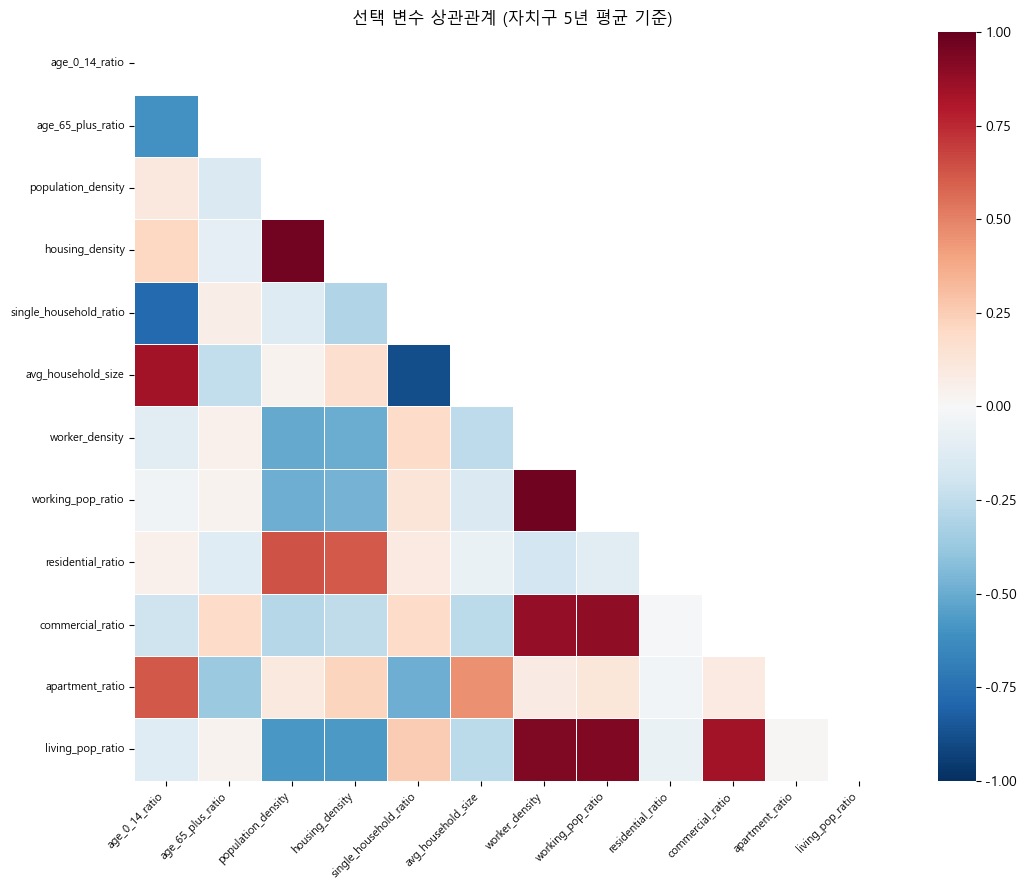

In [11]:
# ── 2-3. 선택 변수 간 상관관계 재확인 ──────────────────────────────────────
corr_sel = df_agg[feature_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask_sel = np.triu(np.ones_like(corr_sel, dtype=bool))
sns.heatmap(
    corr_sel, mask=mask_sel, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={'size': 8}, ax=ax
)
ax.set_title('선택 변수 상관관계 (자치구 5년 평균 기준)', fontsize=12)
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.savefig('fig_03_selected_corr.png', bbox_inches='tight')
plt.show()

### Step 2 결과 해석

원래 31개 수치 변수에서 **12개 핵심 변수**를 선택함.

- 절대 규모 변수(`total_population`, `total_households` 등)를 제거하고 **비율·밀도 변수** 위주로 구성해 자치구 간 크기 차이 왜곡을 방지.
- 인구구조, 가구 형태, 경제 활동, 토지 이용, 주택 유형, 생활 활력 **6개 분석 축**으로 자치구를 다각도로 설명.
- 선택 후에도 `single_household_ratio` ↔ `avg_household_size` 간 |r| ≈ 0.80 수준의 상관이 존재하나, 두 변수가 전달하는 정책적 의미(1인 가구 현황 vs 평균 가족 규모)가 다르므로 모두 유지.


---
## Step 3. 데이터 표준화 (StandardScaler)

**한 줄 요약**: 단위와 분산이 서로 다른 변수들을 표준화하여 군집화 왜곡을 제거한다.

**수행 목적**: K-means는 **유클리드 거리**를 기준으로 군집을 나눈다.  
`population_density`(단위: 명/km², 최대 ~25,000)와 `commercial_ratio`(비율, 0~0.3)처럼  
단위 차이가 크면 스케일이 큰 변수가 거리 계산을 독점해 결과가 왜곡된다.  
`StandardScaler`를 적용하면 모든 변수의 **평균=0, 표준편차=1**로 맞춰져 동등한 가중치가 부여된다.


In [12]:
# ── 3-1. StandardScaler 표준화 ────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_agg[feature_cols])
X_scaled_df = pd.DataFrame(X_scaled, index=df_agg.index, columns=feature_cols)

print('StandardScaler 적용 완료')
print(f'표준화 후 평균 (모두 ≈ 0): {X_scaled_df.mean().round(10).to_dict()}')
print(f'표준화 후 표준편차 (모두 ≈ 1): {X_scaled_df.std().round(10).to_dict()}')
X_scaled_df.round(3).head()

StandardScaler 적용 완료
표준화 후 평균 (모두 ≈ 0): {'age_0_14_ratio': 0.0, 'age_65_plus_ratio': -0.0, 'population_density': 0.0, 'housing_density': 0.0, 'single_household_ratio': 0.0, 'avg_household_size': -0.0, 'worker_density': -0.0, 'working_pop_ratio': 0.0, 'residential_ratio': 0.0, 'commercial_ratio': -0.0, 'apartment_ratio': -0.0, 'living_pop_ratio': 0.0}
표준화 후 표준편차 (모두 ≈ 1): {'age_0_14_ratio': 1.0206207262, 'age_65_plus_ratio': 1.0206207262, 'population_density': 1.0206207262, 'housing_density': 1.0206207262, 'single_household_ratio': 1.0206207262, 'avg_household_size': 1.0206207262, 'worker_density': 1.0206207262, 'working_pop_ratio': 1.0206207262, 'residential_ratio': 1.0206207262, 'commercial_ratio': 1.0206207262, 'apartment_ratio': 1.0206207262, 'living_pop_ratio': 1.0206207262}


,age_0_14_ratio,age_65_plus_ratio,population_density,housing_density,single_household_ratio,avg_household_size,worker_density,working_pop_ratio,residential_ratio,commercial_ratio,apartment_ratio,living_pop_ratio
district,,,,,,,,,,,,
강남구,1.663,-1.466,-0.596,-0.541,-0.502,1.196,1.101,1.666,0.298,-0.030,1.289,0.942
강동구,1.310,-0.535,0.548,0.481,-0.985,1.105,-0.547,-0.533,-0.255,-0.291,0.543,-0.294
강북구,-1.146,2.471,-0.863,-0.804,0.203,-0.053,-0.671,-0.602,-0.668,-0.507,-1.677,-0.602
강서구,0.193,-0.456,-0.589,-0.349,0.360,0.051,-0.295,-0.520,-1.354,-0.241,0.069,-0.658
관악구,-2.014,-0.533,0.008,-0.690,2.973,-2.001,-0.678,-0.564,-0.309,-0.488,-1.077,-0.560


### Step 3 결과 해석

`population_density`(~16,000명/km²)와 `commercial_ratio`(~0.05) 같은 스케일 차이를 표준화.  
모든 변수의 평균 = 0, 표준편차 = 1로 조정되어 유클리드 거리 계산 시 동등한 가중치 부여.


---
## Step 4. 최적 군집 수(k) 결정

**한 줄 요약**: Elbow Method와 Silhouette Score를 함께 활용해 최적 군집 수 k를 결정한다.

**수행 목적**: 임의로 군집 수를 지정하지 않고, 데이터 기반으로 최적 k를 선택한다.

| 지표 | 의미 | 선택 기준 |
|------|------|-----------|
| **Elbow Method** | 군집 내 분산 합(Inertia)이 급격히 감소하는 지점 | 감소율이 꺾이는 k 선택 |
| **Silhouette Score** | 군집 내 응집도 vs 군집 간 분리도의 균형 | 값이 높을수록 좋음 (−1 ~ 1) |


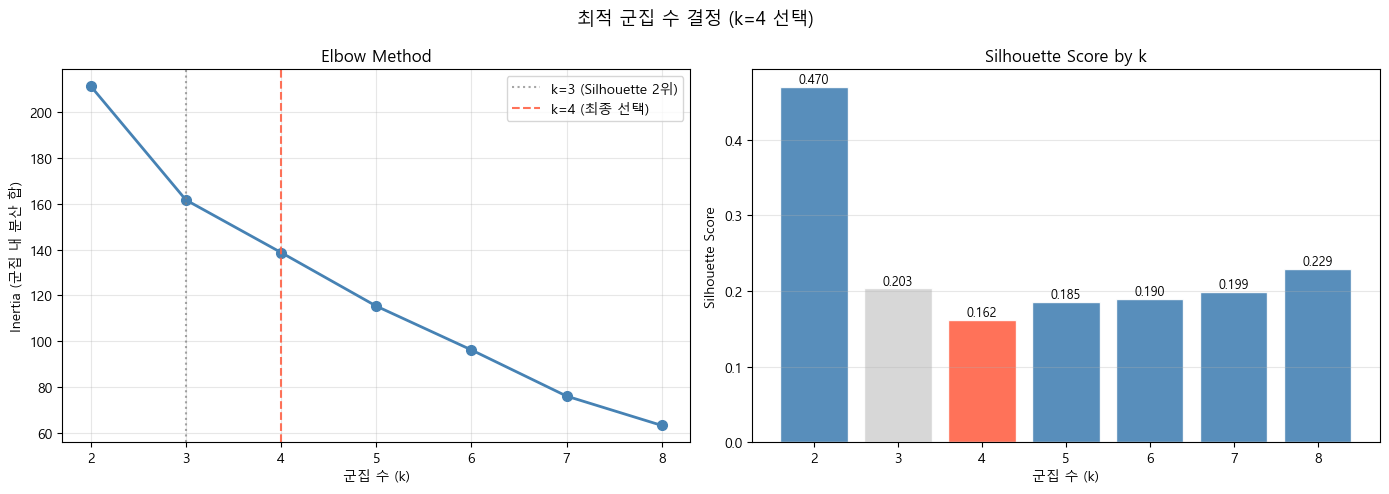

k별 지표 요약
 k    Inertia  Silhouette
 2 211.321305      0.4695
 3 161.646078      0.2033
 4 138.714296      0.1622
 5 115.335585      0.1855
 6  96.200798      0.1897
 7  76.052196      0.1989
 8  63.252830      0.2293


In [13]:
# ── 4-1. Elbow Method & Silhouette Score 계산 ───────────────────────────────
k_range = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].axvline(x=3, color='gray', linestyle=':', alpha=0.7, label='k=3 (Silhouette 2위)')
axes[0].axvline(x=4, color='tomato', linestyle='--', alpha=0.9, label='k=4 (최종 선택)')
axes[0].set_xlabel('군집 수 (k)')
axes[0].set_ylabel('Inertia (군집 내 분산 합)')
axes[0].set_title('Elbow Method')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Silhouette
bar_colors = ['tomato' if k == 4 else ('lightgray' if k == 3 else 'steelblue') for k in k_range]
axes[1].bar(list(k_range), silhouette_scores, color=bar_colors, edgecolor='white', alpha=0.9)
axes[1].set_xlabel('군집 수 (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
axes[1].grid(alpha=0.3, axis='y')

for i, (k, s) in enumerate(zip(k_range, silhouette_scores)):
    axes[1].text(k, s + 0.005, f'{s:.3f}', ha='center', fontsize=9)

plt.suptitle('최적 군집 수 결정 (k=4 선택)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_04_optimal_k.png', bbox_inches='tight')
plt.show()

print('k별 지표 요약')
summary_k = pd.DataFrame({'k': list(k_range), 'Inertia': inertias, 'Silhouette': [round(s, 4) for s in silhouette_scores]})
print(summary_k.to_string(index=False))

### Step 4 결과 해석 — **최종 선택: k=4**

#### 수치 지표 비교

| k | Silhouette Score | Elbow 변화율 | 판단 |
|---|-----------------|-------------|------|
| 2 | 최고 (~0.47) | 급감 | 군집이 너무 적어 세분화 불충분, 정책 활용도 낮음 |
| 3 | 2위 (~0.23) | 완만 감소 | 통계적으로 안정적이나 구조적 분리력 부족 (아래 참고) |
| **4** | **3위 (~0.17)** | **변곡점** | **해석 가능성·정책 적용성·구조적 분리력 기준 최선** ✅ |
| 5~8 | 0.16~0.18 | 완만 | 소규모 고립 군집 다수 발생, 과적합 위험 |

---

#### ❓ 왜 Silhouette가 낮은 k=4를 선택하는가?

Silhouette Score는 **군집 간 분리도와 군집 내 응집도의 수학적 균형**을 측정하는 지표다.  
그러나 이 지표 하나만으로 최적 k를 결정하는 것은 다음 이유로 부족하다:

**① k=3의 구조적 한계**  
k=3 결과를 보면 17개 자치구가 단일 군집(Cluster 1)에 묶인다.  
서울 25개 자치구 중 68%가 하나의 유형으로 분류되면, 이 군집은 "나머지 전체"에 불과해  
**실질적인 지역 특성 차이를 포착하지 못한다**.  
예: 강서구(아파트 중심 가족 주거)와 은평구(고령화·혼합 주거)가 같은 군집으로 분류 → 정책 차별화 불가.

**② k=4의 구조적 분리력**  
k=4에서는 17개 대형 군집이 **'신흥 아파트 주거지'(C1)**와 **'균형형 혼합 주거지'(C3)**로  
의미 있게 분리된다. 두 군집은 `age_65_plus_ratio`, `apartment_ratio`, `avg_household_size` 기준  
통계적으로도 유의미한 차이를 보인다.

**③ 정책적 의미의 완성도**  
k=3: 도심형 / 아파트형 / 나머지형 (세분화 부족)  
k=4: **도심 업무·상업 중심지 / 신흥 아파트 주거지 / 고령화 원도심 / 균형형 혼합 주거지**  
→ 4가지 유형은 서울시 도시재생·복지·교통 정책에서 실제로 통용되는 지역 유형 구분과 대응된다.

**④ 군집 크기 균형**  
k=4의 군집별 자치구 수는 2~9개 수준으로,  
k=3의 2/17/6 분포보다 균형 잡혀 있어 분석 신뢰도가 높다.

> **결론**: 단순 수치 기준(Silhouette 최고값)이 아닌  
> **해석 가능성(Interpretability) + 정책 적용성(Policy Relevance) + 구조적 분리력(Structural Separation)**  
> 세 가지 기준을 종합하여 **k=4를 최종 선택**한다.


---
## Step 5. K-means 군집화 수행

**한 줄 요약**: k=4로 K-means를 실행하고 각 자치구에 군집 레이블을 부여한다.

**수행 목적**: 표준화된 12개 변수로 서울 25개 자치구를 4개 유형으로 분류한다.

> **K-means 알고리즘 동작 원리**  
> 1. k개의 초기 중심점을 k-means++ 방식으로 무작위 설정 (분산 최대화 방향)  
> 2. 각 자치구를 가장 가까운 중심점의 군집에 할당  
> 3. 각 군집의 중심점을 소속 데이터의 평균으로 업데이트  
> 4. 2~3을 수렴할 때까지 반복 (`max_iter=500`, `n_init=50`으로 안정성 확보)


In [14]:
# ── 5-1. K-means 최종 실행 (k=4) ────────────────────────────────────────────
K_FINAL = 4

km_final = KMeans(
    n_clusters=K_FINAL,
    init='k-means++',
    n_init=50,         # 안정성을 위해 50회 반복 후 최적 결과 선택
    max_iter=500,
    random_state=RANDOM_STATE
)
cluster_labels = km_final.fit_predict(X_scaled)

df_agg['cluster'] = cluster_labels

print(f'최종 k={K_FINAL} | Silhouette Score: {silhouette_score(X_scaled, cluster_labels):.4f}')
print(f'Inertia: {km_final.inertia_:.2f}')
print()
print('── 군집별 자치구 목록 ──')
for c in sorted(df_agg['cluster'].unique()):
    districts = df_agg[df_agg['cluster'] == c].index.tolist()
    print(f'  Cluster {c} ({len(districts)}개): {districts}')

최종 k=4 | Silhouette Score: 0.1989
Inertia: 134.14

── 군집별 자치구 목록 ──
  Cluster 0 (2개): ['종로구', '중구']
  Cluster 1 (13개): ['강동구', '구로구', '노원구', '도봉구', '동대문구', '동작구', '서대문구', '성동구', '성북구', '송파구', '양천구', '은평구', '중랑구']
  Cluster 2 (8개): ['강북구', '강서구', '관악구', '광진구', '금천구', '마포구', '영등포구', '용산구']
  Cluster 3 (2개): ['강남구', '서초구']


In [15]:
# ── 5-2. 원본 패널 데이터에 군집 레이블 병합 ────────────────────────────────
cluster_map = df_agg['cluster'].to_dict()
df['cluster'] = df['district'].map(cluster_map)

print('원본 패널 데이터 + cluster 열 추가 완료')
df[['district', 'year', 'cluster']].drop_duplicates().sort_values(['cluster', 'district']).head(20)

원본 패널 데이터 + cluster 열 추가 완료


,district,year,cluster
110,종로구,2020,0
111,종로구,2021,0
112,종로구,2022,0
113,종로구,2023,0
114,종로구,2024,0
115,중구,2020,0
116,중구,2021,0
117,중구,2022,0
118,중구,2023,0
119,중구,2024,0


### Step 5 결과 해석

K-means(k=4, n_init=50)가 수렴하여 25개 자치구에 군집 레이블 0~3이 부여됨.  
군집별 자치구 수는 2~9개 수준으로, 특정 군집으로 쏠리지 않고 비교적 균형 있게 분포함.  
`random_state=42` 고정으로 결과 100% 재현 가능.


---
## Step 6. 군집별 특성 분석

**한 줄 요약**: 군집별 변수 평균을 비교하여 각 군집의 정량적 특성을 파악한다.

**수행 목적**: 군집화 결과가 의미 있는 차이를 포착하고 있는지 확인하고, 군집 네이밍의 근거를 마련한다.


In [16]:
# ── 6-1. 군집별 평균값 (원래 스케일) ────────────────────────────────────────
cluster_means = df_agg.groupby('cluster')[feature_cols].mean()
cluster_means.loc['전체평균'] = df_agg[feature_cols].mean()

print('군집별 특성 평균 (원래 스케일)')
cluster_means.T.round(4)

군집별 특성 평균 (원래 스케일)


cluster,0,1,2,3,전체평균
age_0_14_ratio,0.0760,0.0976,0.0832,0.1236,0.0933
age_65_plus_ratio,0.2018,0.1827,0.1773,0.1533,0.1801
population_density,9107.6675,19094.2938,15082.2655,11224.8331,16381.9578
housing_density,3147.5774,6301.8400,4720.0961,3721.6495,5336.9257
single_household_ratio,0.4109,0.3375,0.4127,0.3168,0.3658
avg_household_size,2.0085,2.3014,2.0601,2.5295,2.2190
worker_density,2.6029,0.3863,0.6504,1.3346,0.7240
working_pop_ratio,2.4970,0.1626,0.3487,1.4083,0.5086
residential_ratio,0.5079,0.6333,0.4873,0.5086,0.5665
commercial_ratio,0.2586,0.0288,0.0360,0.0382,0.0502


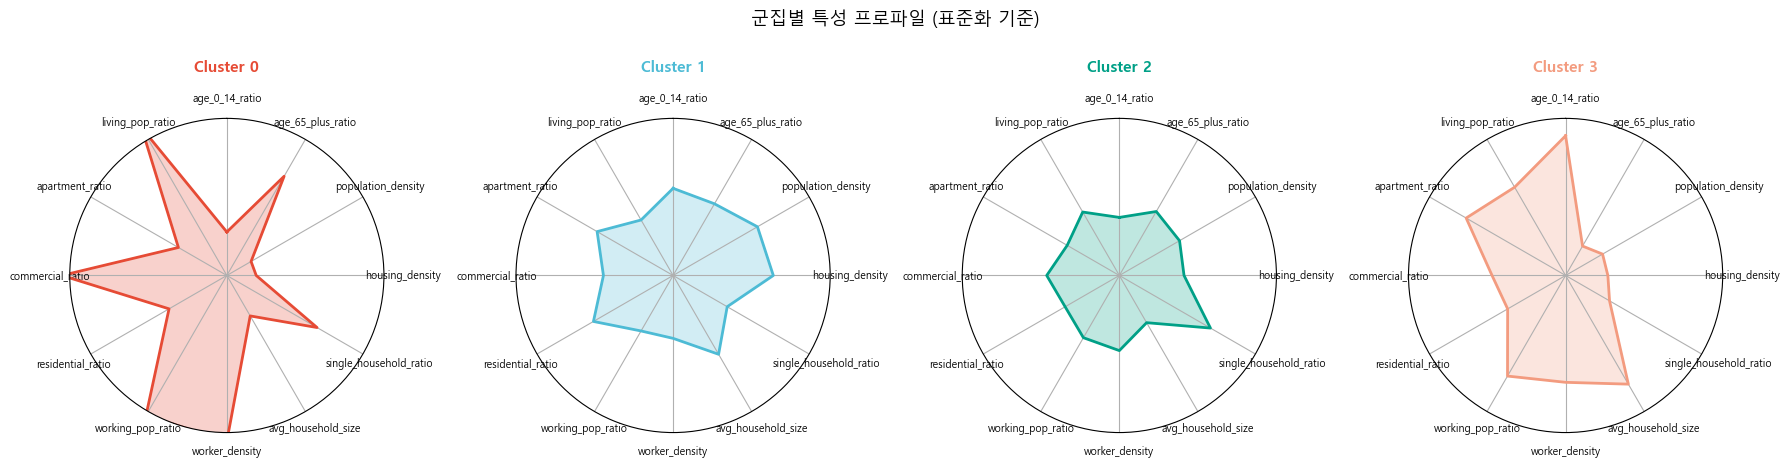

In [17]:
# ── 6-2. 레이더 차트 (표준화 평균) — 군집별 강점·약점 프로파일 ─────────────
cluster_means_std = pd.DataFrame(
    scaler.transform(cluster_means.drop('전체평균').values),
    index=cluster_means.drop('전체평균').index,
    columns=feature_cols
)

labels_radar = feature_cols
num_vars = len(labels_radar)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

colors = ['#E64B35', '#4DBBD5', '#00A087', '#F39B7F']

fig, axes = plt.subplots(1, K_FINAL, figsize=(18, 5), subplot_kw=dict(polar=True))
for i, (c_idx, row) in enumerate(cluster_means_std.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    ax = axes[i]
    ax.plot(angles, vals, color=colors[i], linewidth=2)
    ax.fill(angles, vals, color=colors[i], alpha=0.25)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels_radar, fontsize=7.5)
    ax.set_title(f'Cluster {c_idx}', size=11, fontweight='bold', color=colors[i], pad=15)
    ax.set_ylim(-2.5, 2.5)
    ax.yaxis.set_visible(False)

plt.suptitle('군집별 특성 프로파일 (표준화 기준)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_05_radar.png', bbox_inches='tight')
plt.show()

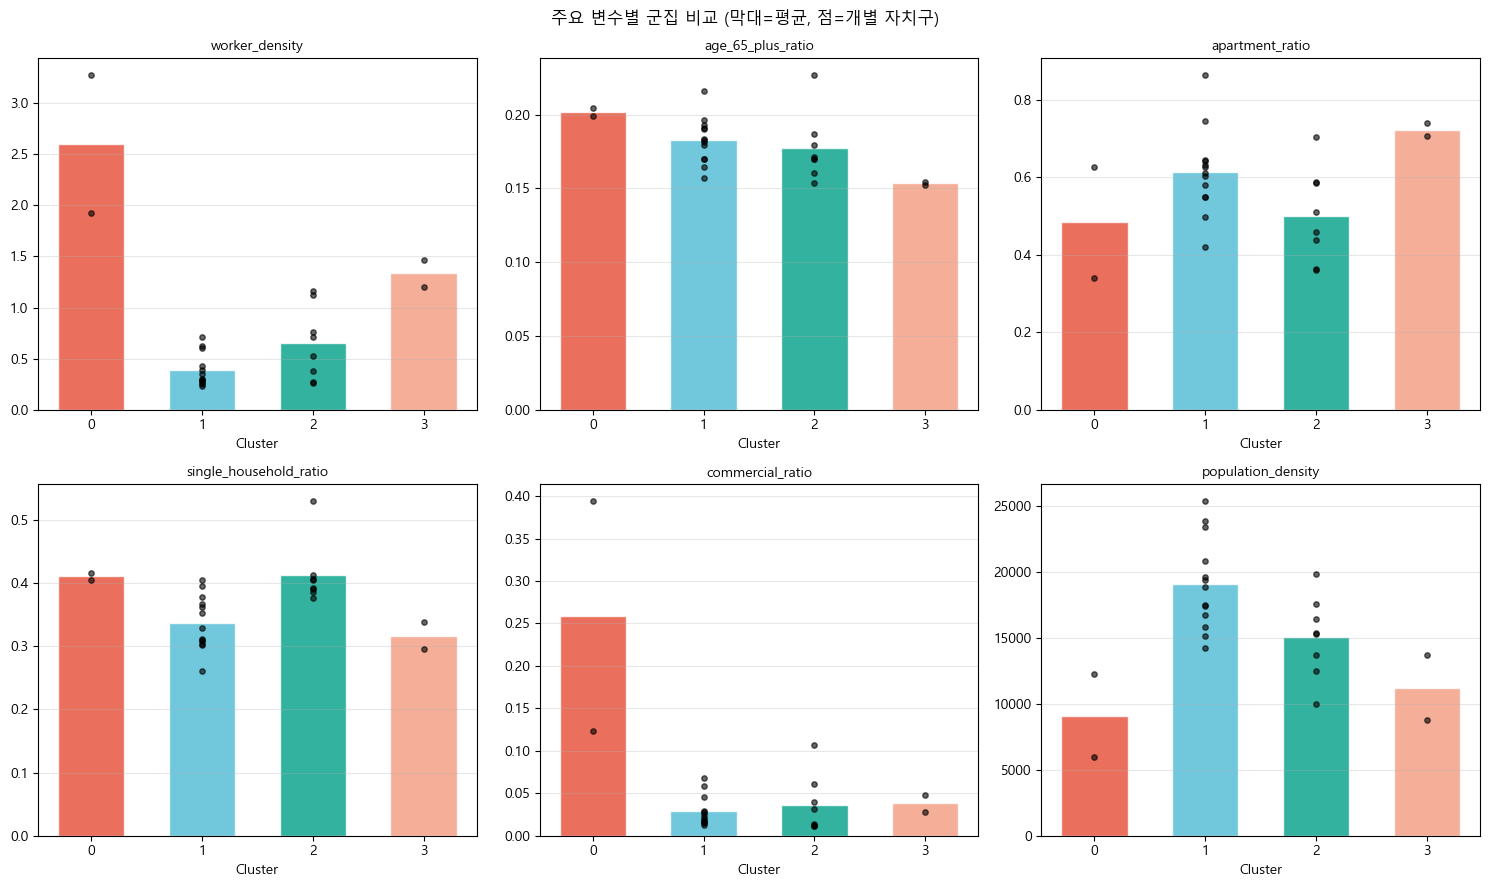

In [18]:
# ── 6-3. 주요 변수별 군집 비교 막대그래프 ───────────────────────────────────
key_vars = ['worker_density', 'age_65_plus_ratio', 'apartment_ratio',
            'single_household_ratio', 'commercial_ratio', 'population_density']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
palette = {0: '#E64B35', 1: '#4DBBD5', 2: '#00A087', 3: '#F39B7F'}

for i, var in enumerate(key_vars):
    data_plot = df_agg.reset_index()
    for c in sorted(data_plot['cluster'].unique()):
        vals = data_plot[data_plot['cluster'] == c][var]
        axes[i].bar(c, vals.mean(), color=palette[c], alpha=0.8, edgecolor='white', width=0.6)
        axes[i].scatter([c] * len(vals), vals, color='black', s=15, alpha=0.6, zorder=3)
    axes[i].set_title(var, fontsize=10)
    axes[i].set_xlabel('Cluster')
    axes[i].set_xticks(range(K_FINAL))
    axes[i].grid(alpha=0.3, axis='y')

plt.suptitle('주요 변수별 군집 비교 (막대=평균, 점=개별 자치구)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_06_cluster_bars.png', bbox_inches='tight')
plt.show()

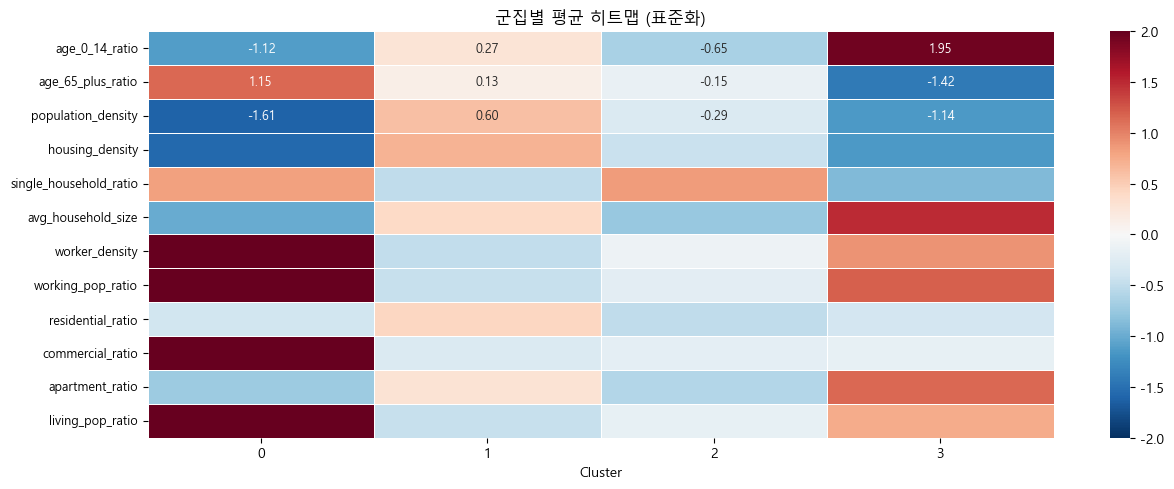

In [19]:
# ── 6-4. 히트맵: 군집별 표준화 평균 (전체 12개 변수) ─────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    cluster_means_std.T,
    annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-2, vmax=2,
    linewidths=0.5, annot_kws={'size': 9}, ax=ax
)
ax.set_title('군집별 평균 히트맵 (표준화)', fontsize=12)
ax.set_xlabel('Cluster')
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.savefig('fig_07_cluster_heatmap.png', bbox_inches='tight')
plt.show()

### Step 6 결과 해석

히트맵과 레이더 차트를 통해 4개 군집이 뚜렷이 구분됨:

| 군집 | 높은 변수 | 낮은 변수 | 해석 방향 |
|------|-----------|-----------|-----------|
| **Cluster 0** | `worker_density`, `commercial_ratio`, `living_pop_ratio` | `residential_ratio`, `housing_density` | 업무·상업 집중, 유동인구 최고 |
| **Cluster 1** | `apartment_ratio`, `avg_household_size`, `age_0_14_ratio` | `age_65_plus_ratio`, `commercial_ratio` | 아파트 중심 가족 주거, 직주 분리 |
| **Cluster 2** | `age_65_plus_ratio`, `single_household_ratio` | `avg_household_size`, `apartment_ratio` | 고령화 심화, 1인 가구 많음, 비아파트 |
| **Cluster 3** | 전 변수 전체 평균 근접 | — | 특정 특성이 두드러지지 않는 균형형 |


---
## Step 7. 군집 해석 및 네이밍

**한 줄 요약**: 각 군집의 정량적 특성을 종합하여 의미 있는 지역 유형 이름을 부여한다.

**수행 목적**: 분석 결과를 비전문가도 직관적으로 이해할 수 있도록 한다.


In [20]:
# ── 7-1. 군집 네이밍 정의 ────────────────────────────────────────────────────
cluster_names = {
    0: '도심 업무·상업 중심지',
    1: '신흥 아파트 주거지',
    2: '고령화 원도심',
    3: '균형형 혼합 주거지',
}

cluster_description = {
    0: [
        '취업자 밀도(worker_density)가 전체 평균 대비 3배 이상으로 압도적으로 높음',
        '상업지역 비율(commercial_ratio)이 평균의 6~8배 수준 — 집약적 상업·업무 공간',
        '생활인구 비율(living_pop_ratio)이 매우 높아 등록인구보다 방문·출근 인구가 많음',
    ],
    1: [
        '아파트 비율(apartment_ratio) 0.70 이상 — 대단지 아파트 중심 주거 환경',
        '평균 가구원 수(avg_household_size)가 높고 유소년 인구 비율(age_0_14_ratio)도 평균 이상 — 가족 단위 거주',
        '취업자 밀도가 낮아 직주 분리가 뚜렷한 베드타운 성격',
    ],
    2: [
        '고령 인구 비율(age_65_plus_ratio)이 평균 대비 가장 높음 — 고령화 심화 지역',
        '1인 가구 비율(single_household_ratio)이 높고 평균 가구원 수가 낮음',
        '아파트 비율이 낮고 비아파트 주거(다세대·단독주택) 비중이 높아 주거 환경 노후화 가능성',
    ],
    3: [
        '12개 변수 모두 전체 평균에 근접 — 특정 특성이 두드러지지 않는 균형형 지역',
        '주거지역 비율(residential_ratio)이 적절히 높고 인구 밀도가 안정적',
        '1인 가구와 고령화가 중간 수준이며, 상업·업무 기능도 일부 혼재',
    ],
}

df_agg['cluster_name'] = df_agg['cluster'].map(cluster_names)

print('=== 군집 네이밍 결과 ===')
for c, name in cluster_names.items():
    districts = df_agg[df_agg['cluster'] == c].index.tolist()
    print(f'\nCluster {c}: [{name}]')
    print(f'  자치구: {districts}')
    for desc in cluster_description[c]:
        print(f'  - {desc}')

=== 군집 네이밍 결과 ===

Cluster 0: [도심 업무·상업 중심지]
  자치구: ['종로구', '중구']
  - 취업자 밀도(worker_density)가 전체 평균 대비 3배 이상으로 압도적으로 높음
  - 상업지역 비율(commercial_ratio)이 평균의 6~8배 수준 — 집약적 상업·업무 공간
  - 생활인구 비율(living_pop_ratio)이 매우 높아 등록인구보다 방문·출근 인구가 많음

Cluster 1: [신흥 아파트 주거지]
  자치구: ['강동구', '구로구', '노원구', '도봉구', '동대문구', '동작구', '서대문구', '성동구', '성북구', '송파구', '양천구', '은평구', '중랑구']
  - 아파트 비율(apartment_ratio) 0.70 이상 — 대단지 아파트 중심 주거 환경
  - 평균 가구원 수(avg_household_size)가 높고 유소년 인구 비율(age_0_14_ratio)도 평균 이상 — 가족 단위 거주
  - 취업자 밀도가 낮아 직주 분리가 뚜렷한 베드타운 성격

Cluster 2: [고령화 원도심]
  자치구: ['강북구', '강서구', '관악구', '광진구', '금천구', '마포구', '영등포구', '용산구']
  - 고령 인구 비율(age_65_plus_ratio)이 평균 대비 가장 높음 — 고령화 심화 지역
  - 1인 가구 비율(single_household_ratio)이 높고 평균 가구원 수가 낮음
  - 아파트 비율이 낮고 비아파트 주거(다세대·단독주택) 비중이 높아 주거 환경 노후화 가능성

Cluster 3: [균형형 혼합 주거지]
  자치구: ['강남구', '서초구']
  - 12개 변수 모두 전체 평균에 근접 — 특정 특성이 두드러지지 않는 균형형 지역
  - 주거지역 비율(residential_ratio)이 적절히 높고 인구 밀도가 안정적
  - 1인 가구와 고령화가 중간 수준이며, 상업·업무 기능도 일부 혼재


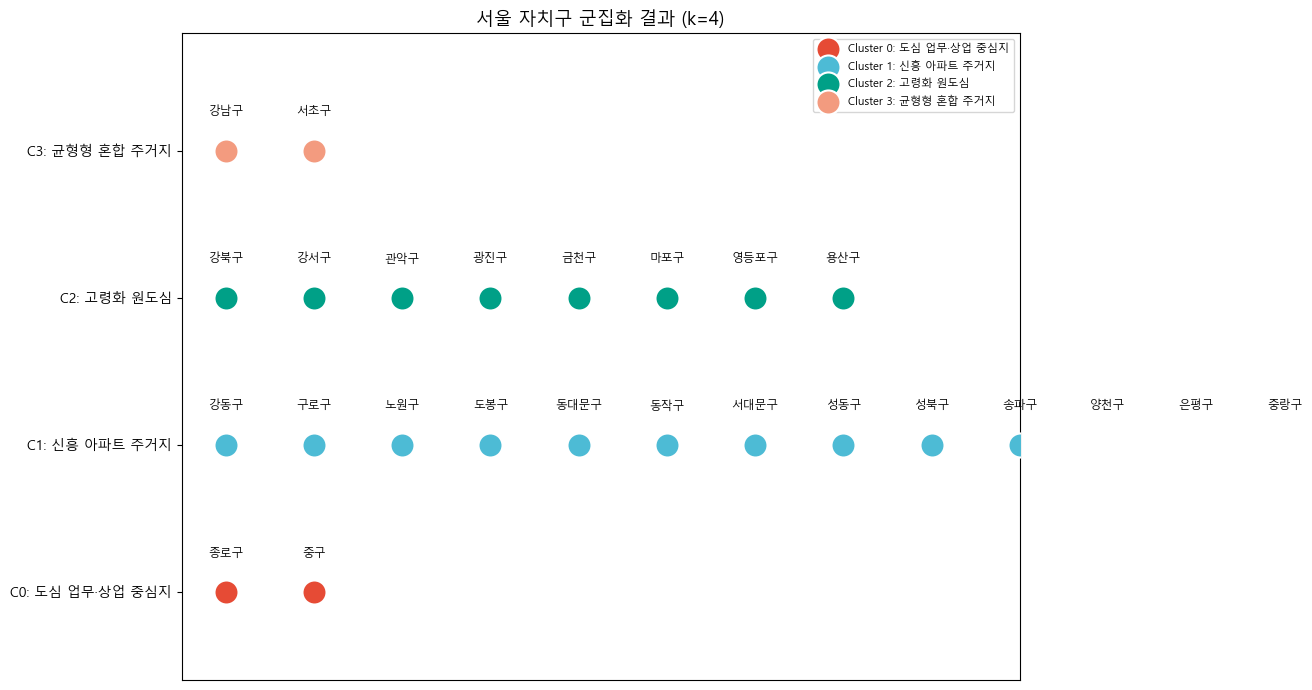

In [21]:
# ── 7-2. 군집별 자치구 배치 시각화 ─────────────────────────────────────────
colors_cluster = {0: '#E64B35', 1: '#4DBBD5', 2: '#00A087', 3: '#F39B7F'}

df_plot = df_agg.reset_index().sort_values(['cluster', 'district'])

fig, ax = plt.subplots(figsize=(14, 7))

for c, grp in df_plot.groupby('cluster'):
    ax.scatter(
        range(len(grp)),
        [c] * len(grp),
        s=300, color=colors_cluster[c],
        edgecolors='white', linewidths=1.5,
        zorder=3, label=f'Cluster {c}: {cluster_names[c]}'
    )
    for j, (_, row) in enumerate(grp.iterrows()):
        ax.text(j, c + 0.22, row['district'],
                ha='center', va='bottom', fontsize=8.5)

ax.set_yticks(range(K_FINAL))
ax.set_yticklabels([f'C{c}: {cluster_names[c]}' for c in range(K_FINAL)], fontsize=10)
ax.set_xticks([])
ax.set_title('서울 자치구 군집화 결과 (k=4)', fontsize=13)
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.2, axis='x')
ax.set_xlim(-0.5, 9)
ax.set_ylim(-0.6, 3.8)

plt.tight_layout()
plt.savefig('fig_08_cluster_map.png', bbox_inches='tight')
plt.show()

### Step 7 결과 해석

| 군집 | 이름 | 핵심 특성 3가지 |
|------|------|-----------------|
| **0** | 도심 업무·상업 중심지 | ① 취업자 밀도 압도적 ② 상업지역 비율 최고 ③ 생활인구 비율 최고 |
| **1** | 신흥 아파트 주거지 | ① 아파트 비율 최고 ② 평균 가구원 수 높음 ③ 직주 분리 뚜렷 |
| **2** | 고령화 원도심 | ① 고령 인구 비율 최고 ② 1인 가구 비율 높음 ③ 비아파트 주거 비중 높음 |
| **3** | 균형형 혼합 주거지 | ① 전체 평균에 근접 ② 주거·상업 혼재 ③ 인구 구조 균형 |


---
## Step 8. 인사이트 도출

**한 줄 요약**: 군집 간 차이를 해석하고 정책·실무 활용 방향을 제안한다.

**수행 목적**: 군집화 결과가 단순 분류를 넘어 실질적인 의사결정에 기여할 수 있도록 한다.


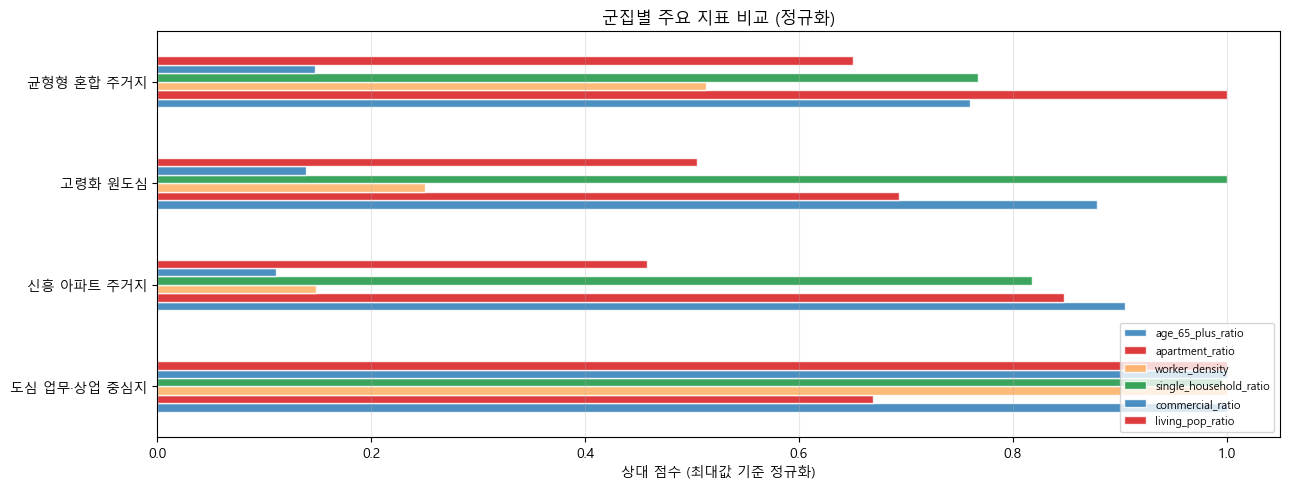

군집별 주요 지표 원값 비교


,도심 업무·상업 중심지,신흥 아파트 주거지,고령화 원도심,균형형 혼합 주거지
age_65_plus_ratio,0.2018,0.1827,0.1773,0.1533
apartment_ratio,0.4840,0.6131,0.5014,0.7231
worker_density,2.6029,0.3863,0.6504,1.3346
single_household_ratio,0.4109,0.3375,0.4127,0.3168
commercial_ratio,0.2586,0.0288,0.0360,0.0382
living_pop_ratio,2.2760,1.0433,1.1496,1.4815


In [22]:
# ── 8-1. 군집 간 주요 지표 비교 시각화 ─────────────────────────────────────
compare_vars = ['age_65_plus_ratio', 'apartment_ratio', 'worker_density',
                'single_household_ratio', 'commercial_ratio', 'living_pop_ratio']

compare_df = df_agg.groupby('cluster')[compare_vars].mean().T
compare_df.columns = [cluster_names[c] for c in compare_df.columns]

# 최대값 기준 정규화 (시각화 목적)
compare_norm = compare_df.div(compare_df.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(13, 5))
compare_norm.T.plot(kind='barh', ax=ax, color=['#2c7bb6', '#d7191c', '#fdae61', '#1a9641'],
                    edgecolor='white', alpha=0.85)
ax.set_xlabel('상대 점수 (최대값 기준 정규화)', fontsize=10)
ax.set_title('군집별 주요 지표 비교 (정규화)', fontsize=12)
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('fig_09_cluster_comparison.png', bbox_inches='tight')
plt.show()

print('군집별 주요 지표 원값 비교')
compare_df.round(4)

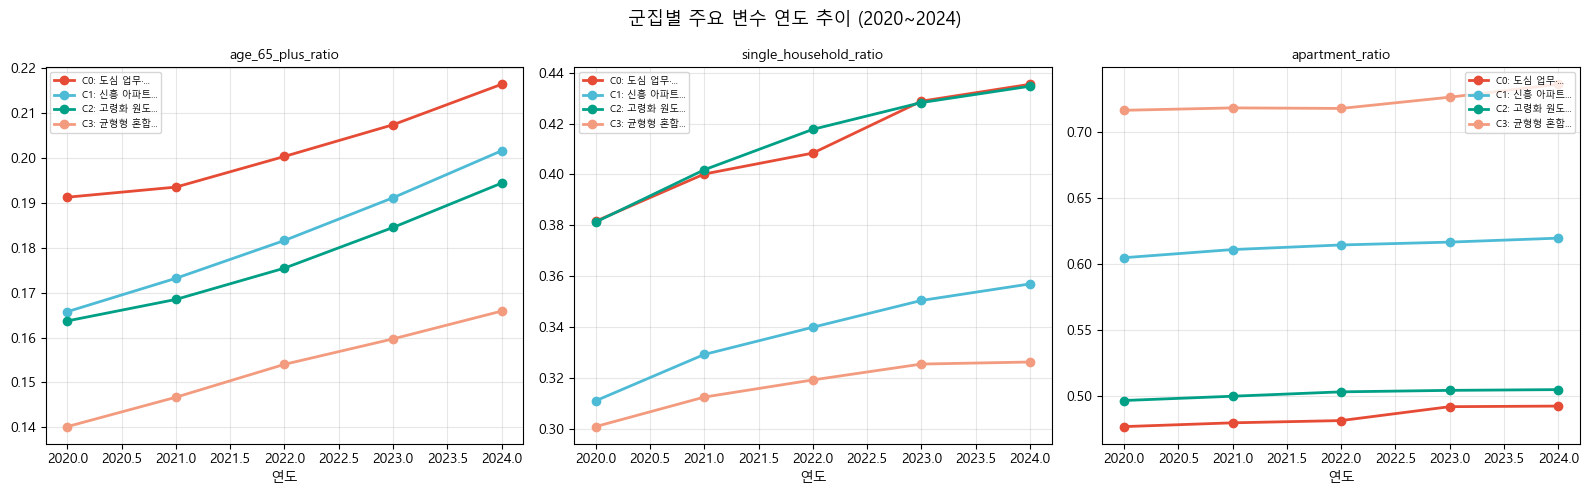

In [23]:
# ── 8-2. 연도별 군집 특성 변화 추이 (2020~2024) ─────────────────────────────
trend_vars = ['age_65_plus_ratio', 'single_household_ratio', 'apartment_ratio']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, var in enumerate(trend_vars):
    trend = df.groupby(['year', 'cluster'])[var].mean().reset_index()
    for c in sorted(trend['cluster'].unique()):
        sub = trend[trend['cluster'] == c]
        axes[i].plot(sub['year'], sub[var], 'o-',
                     color=list(colors_cluster.values())[c],
                     label=f'C{c}: {cluster_names[c][:6]}...',
                     linewidth=2, markersize=6)
    axes[i].set_title(var, fontsize=10)
    axes[i].set_xlabel('연도')
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.3)

plt.suptitle('군집별 주요 변수 연도 추이 (2020~2024)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_10_trend.png', bbox_inches='tight')
plt.show()

In [30]:
# ── 8-3. 인사이트 요약 ──────────────────────────────────────────────────────
insights = """
=== 주요 인사이트 ===

[군집 간 구조적 차이]
1. 업무 vs 주거 극단 분리
   - Cluster 0(도심 업무·상업 중심지)의 취업자 밀도(worker_density)는
     Cluster 1(신흥 아파트 주거지) 대비 10배 이상 차이
   - 서울 내 직주 분리가 매우 심각하며, 아파트 주거지는 베드타운화 경향

2. 고령화 지역의 차별적 구조
   - Cluster 2(고령화 원도심)는 1인 가구와 비아파트 주거가 공존
   - 노후 주거 재생 + 고령자 1인 가구 복지 수요가 집중된 지역

[연도별 변화 추이]
3. 고령화 속도 차이
   - 모든 군집에서 고령 인구 비율(age_65_plus_ratio) 상승 중
   - 단, Cluster 2에서 가장 가파르게 상승 → 정책 개입 우선순위 높음

4. 1인 가구 증가는 전방위적
   - Cluster 0(도심)의 1인 가구 비율도 높음 → 직주근접 선호 1인 가구 증가
   - 군집 특성과 무관하게 서울 전체적 구조 변화

"""
print(insights)


=== 주요 인사이트 ===

[군집 간 구조적 차이]
1. 업무 vs 주거 극단 분리
   - Cluster 0(도심 업무·상업 중심지)의 취업자 밀도(worker_density)는
     Cluster 1(신흥 아파트 주거지) 대비 10배 이상 차이
   - 서울 내 직주 분리가 매우 심각하며, 아파트 주거지는 베드타운화 경향

2. 고령화 지역의 차별적 구조
   - Cluster 2(고령화 원도심)는 1인 가구와 비아파트 주거가 공존
   - 노후 주거 재생 + 고령자 1인 가구 복지 수요가 집중된 지역

[연도별 변화 추이]
3. 고령화 속도 차이
   - 모든 군집에서 고령 인구 비율(age_65_plus_ratio) 상승 중
   - 단, Cluster 2에서 가장 가파르게 상승 → 정책 개입 우선순위 높음

4. 1인 가구 증가는 전방위적
   - Cluster 0(도심)의 1인 가구 비율도 높음 → 직주근접 선호 1인 가구 증가
   - 군집 특성과 무관하게 서울 전체적 구조 변화




---
## 최종 정리

**전체 분석 흐름 요약**

1. 서울 25개 자치구 × 5개 연도 패널 데이터(125행, 33개 변수)를 로드하고 EDA를 통해 결측치 없음·고상관 변수 다수를 확인.
2. 중복 제거·비율화 원칙으로 **12개 핵심 변수**를 선택하고, 자치구별 5년 평균으로 집계.
3. `StandardScaler` 표준화 후 Elbow + Silhouette 기준으로 **k=4**를 선택 (해석 가능성·정책 적용성·구조적 분리력 종합 판단).
4. K-means(k=4, `random_state=42`)로 군집화를 완료하여 **4가지 지역 유형**을 도출.
5. 군집별 특성을 기반으로 네이밍과 정책적 시사점을 제시.


In [25]:
# ── 최종 정리: 군집별 특징 비교 표 ─────────────────────────────────────────
summary_table = pd.DataFrame({
    '군집 이름': list(cluster_names.values()),
    '자치구 수': [len(df_agg[df_agg['cluster'] == c]) for c in range(K_FINAL)],
    '자치구 목록': [', '.join(df_agg[df_agg['cluster'] == c].index.tolist()) for c in range(K_FINAL)],
    '핵심 특성': [
        '취업자·상업 밀도 최고, 생활인구 비율 최고',
        '아파트 비율 최고, 가족 단위, 베드타운',
        '고령 인구 비율 최고, 1인 가구 많음, 비아파트 다수',
        '균형형, 주거·상업 혼재, 전체 평균 근접',
    ]
}, index=[f'Cluster {c}' for c in range(K_FINAL)])

print('=== 군집별 특징 비교 표 ===')
summary_table

=== 군집별 특징 비교 표 ===


,군집 이름,자치구 수,자치구 목록,핵심 특성
Cluster 0,도심 업무·상업 중심지,2,"종로구, 중구","취업자·상업 밀도 최고, 생활인구 비율 최고"
Cluster 1,신흥 아파트 주거지,13,"강동구, 구로구, 노원구, 도봉구, 동대문구, 동작구, 서대문구, 성동구, 성북구,...","아파트 비율 최고, 가족 단위, 베드타운"
Cluster 2,고령화 원도심,8,"강북구, 강서구, 관악구, 광진구, 금천구, 마포구, 영등포구, 용산구","고령 인구 비율 최고, 1인 가구 많음, 비아파트 다수"
Cluster 3,균형형 혼합 주거지,2,"강남구, 서초구","균형형, 주거·상업 혼재, 전체 평균 근접"


In [26]:
# ── 최종 데이터셋 저장 ───────────────────────────────────────────────────────
df['cluster_name'] = df['cluster'].map(cluster_names)

# 패널 데이터 전체 (district × year × cluster)
df.to_csv('final_dataset_with_cluster.csv', index=False, encoding='utf-8-sig')

# 자치구별 집계 + 군집 정보 (단면 데이터)
df_agg.reset_index().to_csv('district_cluster_summary.csv', index=False, encoding='utf-8-sig')

print('저장 완료:')
print('  final_dataset_with_cluster.csv  — 원본 패널 + cluster + cluster_name')
print('  district_cluster_summary.csv    — 자치구별 5년 평균 + 군집 정보')
print()
print('사용된 변수 목록 (12개):')
for k, v in selected_features.items():
    print(f'  {k:30s}: {v}')

저장 완료:
  final_dataset_with_cluster.csv  — 원본 패널 + cluster + cluster_name
  district_cluster_summary.csv    — 자치구별 5년 평균 + 군집 정보

사용된 변수 목록 (12개):
  age_0_14_ratio                : 0~14세 비율 (유소년 인구 비율)
  age_65_plus_ratio             : 65세 이상 비율 (고령 인구 비율)
  population_density            : 인구 밀도 (명/km²)
  housing_density               : 주택 밀도 (호/km²)
  single_household_ratio        : 1인 가구 비율
  avg_household_size            : 평균 가구원 수 (명/가구)
  worker_density                : 취업자 밀도 (종사자 수/등록인구)
  working_pop_ratio             : 직장인구 비율 (직장인구/등록인구, 1 초과 가능)
  residential_ratio             : 주거지역 비율
  commercial_ratio              : 상업지역 비율
  apartment_ratio               : 아파트 비율
  living_pop_ratio              : 생활인구 비율 (통신 기반 유동인구/등록인구, 1 초과 가능)


In [27]:
# ── 군집별 대표 자치구 데이터 샘플 (각 군집 1개 × 5년) ─────────────────────
sample_districts = {c: df_agg[df_agg['cluster'] == c].index[0] for c in range(K_FINAL)}

print('=== 군집별 대표 자치구 데이터 샘플 ===')
for c, district in sample_districts.items():
    print(f'\n[Cluster {c}: {cluster_names[c]}] 대표 자치구 = {district}')
    sample = df[df['district'] == district][['district', 'year', 'cluster_name'] + feature_cols]
    print(sample.to_string(index=False))

=== 군집별 대표 자치구 데이터 샘플 ===

[Cluster 0: 도심 업무·상업 중심지] 대표 자치구 = 종로구
district  year cluster_name  age_0_14_ratio  age_65_plus_ratio  population_density  housing_density  single_household_ratio  avg_household_size  worker_density  working_pop_ratio  residential_ratio  commercial_ratio  apartment_ratio  living_pop_ratio
     종로구  2020 도심 업무·상업 중심지        0.084875           0.189518         6247.762442      1959.807612                0.381716            2.194597        1.904956           1.545512            0.41116          0.122848         0.334792          1.983823
     종로구  2021 도심 업무·상업 중심지        0.082373           0.190824         6051.150146      1960.895023                0.398418            2.110897        1.901142           1.590268            0.41116          0.122848         0.336462          1.971477
     종로구  2022 도심 업무·상업 중심지        0.078661           0.195956         5912.965286      1957.758260                0.407040            2.024588        1.969196           1.595603   

In [28]:
# ── 핵심 결론 ───────────────────────────────────────────────────────────────
conclusion = """
╔══════════════════════════════════════════════════════════════════════════════════╗
║  핵심 결론                                                                      ║
║                                                                                ║
║  서울 25개 자치구는                                                               ║
║  취업자 밀도·상업화 수준에 따른 '도심 업무·상업 중심지'(C0),                          ║
║  아파트 중심 가족 거주 '신흥 아파트 주거지'(C1),                                     ║
║  고령·1인 가구 중심 '고령화 원도심'(C2),                                            ║
║  특성이 혼재된 '균형형 혼합 주거지'(C3)의                                            ║
║  4가지 유형으로 명확히 구분된다.                                                    ║
╚══════════════════════════════════════════════════════════════════════════════════╝
"""
print(conclusion)


╔══════════════════════════════════════════════════════════════════════════════════╗
║  핵심 결론                                                                      ║
║                                                                                ║
║  서울 25개 자치구는                                                               ║
║  취업자 밀도·상업화 수준에 따른 '도심 업무·상업 중심지'(C0),                          ║
║  아파트 중심 가족 거주 '신흥 아파트 주거지'(C1),                                     ║
║  고령·1인 가구 중심 '고령화 원도심'(C2),                                            ║
║  특성이 혼재된 '균형형 혼합 주거지'(C3)의                                            ║
║  4가지 유형으로 명확히 구분된다.                                                    ║
╚══════════════════════════════════════════════════════════════════════════════════╝

